<a href="https://colab.research.google.com/github/YakubuNaat/machine-leaning/blob/main/ML_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--

In [ ]:
import os
import warnings

# Tools

import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np  # linear algebra
from itertools import cycle
import matplotlib.pyplot as plt
from sklearn import decomposition, datasets
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
# Models
from sklearn import svm, linear_model
from xgboost import XGBRegressor, plot_importance
from sklearn.linear_model import LinearRegression, TheilSenRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor, plot_importance
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC


# Utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score,KFold
import joblib
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
from sklearn.metrics import accuracy_score, precision_score
from sklearn.multioutput import MultiOutputRegressor

# Load and preprocess the data

In [ ]:
df = pd.read_csv("formation_energies.csv")
df.head()

,material_id,formula_pretty,formation_energy_per_atom
0,mp-1094120,Nb,0.189748
1,mp-1120447,Si,0.372510
2,mp-1179802,Rb,0.053649
3,mp-1180008,O2,0.419854
4,mp-1180064,O2,0.387014


In [ ]:
print(len(df))
df = df.dropna(subset=["vbm", "fermi_energy"])
print(len(df))

178391
96620


In [ ]:
df.head(20)

,mat_ID,fermi_energy,vbm,cbm,descriptor_1,descriptor_2,descriptor_3,descriptor_4,descriptor_5,descriptor_6,...,descriptor_16,descriptor_17,descriptor_18,descriptor_19,descriptor_20,descriptor_21,descriptor_22,descriptor_23,descriptor_24,descriptor_25
0,mp-1094120,4.794354,4.8064,4.7806,226.839615,12,8.161255615763505 g cm^-3,41.0,0.0,1.45,...,2.18,0.000000e+00,54.00000,0.000000e+00,2750.0,0.000000e+00,3.037563,0.234792,1,triclinic
3,mp-1180008,-3.121461,-3.1275,-1.8502,199.450061,12,1.5984529792162891 g cm^-3,8.0,0.0,0.60,...,1.52,2.220446e-16,0.02658,3.469447e-18,54.8,7.105427e-15,3.188103,0.908462,1,triclinic
4,mp-1180064,-1.547842,-1.5692,-1.5269,159.269552,10,1.668092138997967 g cm^-3,8.0,0.0,0.60,...,1.52,0.000000e+00,0.02658,0.000000e+00,54.8,0.000000e+00,2.975312,0.906406,1,triclinic
6,mp-1197903,-0.755859,-0.7805,-0.7008,1547.569426,80,1.0309966703255178 g cm^-3,6.0,0.0,0.70,...,1.70,2.220446e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,6.968453,2.772236,1,triclinic
7,mp-1244913,2.131824,2.0262,2.1322,1190.353192,100,1.675488980743921 g cm^-3,6.0,0.0,0.70,...,1.70,8.881784e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,5.097015,1.447221,1,triclinic
11,mp-1244964,2.510756,2.4387,2.5111,1126.924923,100,1.7697928363919535 g cm^-3,6.0,0.0,0.70,...,1.70,8.881784e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,5.027698,1.450973,1,triclinic
12,mp-1244971,6.391806,6.3907,6.3940,1921.073773,100,2.4276563765852774 g cm^-3,14.0,0.0,1.10,...,2.10,0.000000e+00,150.00000,0.000000e+00,1687.0,0.000000e+00,5.995142,1.616790,1,triclinic
16,mp-1245041,6.502809,6.4827,6.5183,1918.192246,100,2.431303226216085 g cm^-3,14.0,0.0,1.10,...,2.10,0.000000e+00,150.00000,0.000000e+00,1687.0,0.000000e+00,5.938336,1.553370,1,triclinic
22,mp-1245164,5.621518,5.6214,5.6216,1751.277086,100,4.538689174156666 g cm^-3,22.0,0.0,1.40,...,2.11,4.440892e-16,22.00000,0.000000e+00,1941.0,0.000000e+00,5.814221,1.572699,1,triclinic
30,mp-1403870,5.190240,5.1912,5.1771,174.107690,8,2.1429068365424007 g cm^-3,14.0,0.0,1.10,...,2.10,0.000000e+00,150.00000,0.000000e+00,1687.0,0.000000e+00,3.137995,0.831066,1,triclinic


In [ ]:
df["descriptor_3"] = df["descriptor_3"].str.replace(" g cm\^-3", "", regex=True).astype(float)

In [ ]:
df.head()

,mat_ID,fermi_energy,vbm,cbm,descriptor_1,descriptor_2,descriptor_3,descriptor_4,descriptor_5,descriptor_6,...,descriptor_16,descriptor_17,descriptor_18,descriptor_19,descriptor_20,descriptor_21,descriptor_22,descriptor_23,descriptor_24,descriptor_25
0,mp-1094120,4.794354,4.8064,4.7806,226.839615,12,8.161256,41.0,0.0,1.45,...,2.18,0.000000e+00,54.00000,0.000000e+00,2750.0,0.000000e+00,3.037563,0.234792,1,triclinic
3,mp-1180008,-3.121461,-3.1275,-1.8502,199.450061,12,1.598453,8.0,0.0,0.60,...,1.52,2.220446e-16,0.02658,3.469447e-18,54.8,7.105427e-15,3.188103,0.908462,1,triclinic
4,mp-1180064,-1.547842,-1.5692,-1.5269,159.269552,10,1.668092,8.0,0.0,0.60,...,1.52,0.000000e+00,0.02658,0.000000e+00,54.8,0.000000e+00,2.975312,0.906406,1,triclinic
6,mp-1197903,-0.755859,-0.7805,-0.7008,1547.569426,80,1.030997,6.0,0.0,0.70,...,1.70,2.220446e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,6.968453,2.772236,1,triclinic
7,mp-1244913,2.131824,2.0262,2.1322,1190.353192,100,1.675489,6.0,0.0,0.70,...,1.70,8.881784e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,5.097015,1.447221,1,triclinic


In [ ]:
df = df.drop(columns=["descriptor_25"])

In [ ]:
df = df.drop(columns=["mat_ID"])

In [ ]:
df.head()

,fermi_energy,vbm,cbm,descriptor_1,descriptor_2,descriptor_3,descriptor_4,descriptor_5,descriptor_6,descriptor_7,...,descriptor_15,descriptor_16,descriptor_17,descriptor_18,descriptor_19,descriptor_20,descriptor_21,descriptor_22,descriptor_23,descriptor_24
0,4.794354,4.8064,4.7806,226.839615,12,8.161256,41.0,0.0,1.45,0.000000e+00,...,0,2.18,0.000000e+00,54.00000,0.000000e+00,2750.0,0.000000e+00,3.037563,0.234792,1
3,-3.121461,-3.1275,-1.8502,199.450061,12,1.598453,8.0,0.0,0.60,1.110223e-16,...,0,1.52,2.220446e-16,0.02658,3.469447e-18,54.8,7.105427e-15,3.188103,0.908462,1
4,-1.547842,-1.5692,-1.5269,159.269552,10,1.668092,8.0,0.0,0.60,1.110223e-16,...,0,1.52,0.000000e+00,0.02658,0.000000e+00,54.8,0.000000e+00,2.975312,0.906406,1
6,-0.755859,-0.7805,-0.7008,1547.569426,80,1.030997,6.0,0.0,0.70,1.110223e-16,...,0,1.70,2.220446e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,6.968453,2.772236,1
7,2.131824,2.0262,2.1322,1190.353192,100,1.675489,6.0,0.0,0.70,2.220446e-16,...,0,1.70,8.881784e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,5.097015,1.447221,1


# FEATURE IMPORTANCE TEST

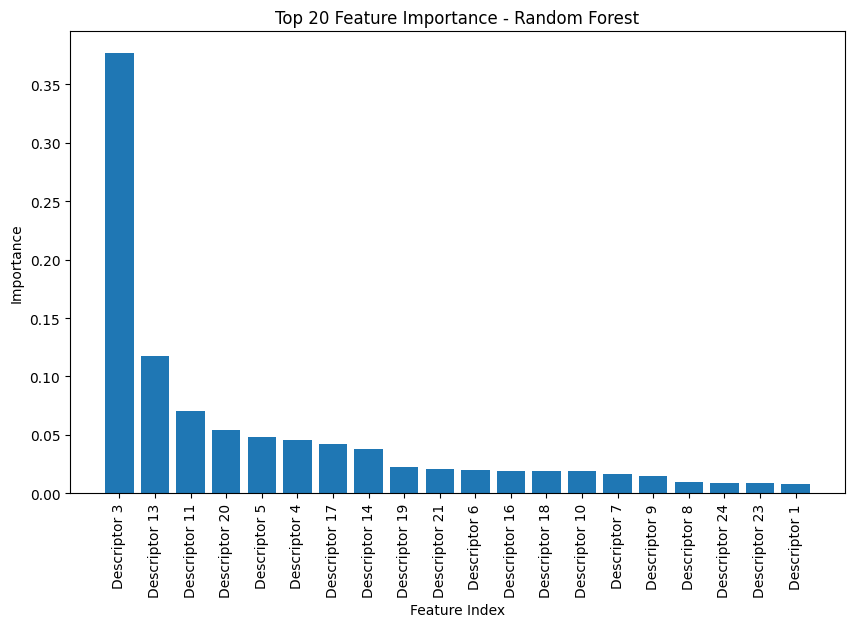

<Figure size 1000x600 with 0 Axes>

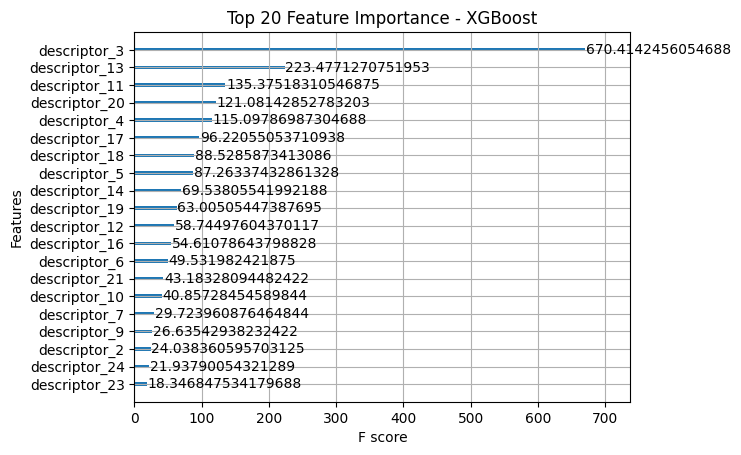

Top 10 Features (Random Forest):
Descriptor 3: 0.3765
Descriptor 13: 0.1179
Descriptor 11: 0.0709
Descriptor 20: 0.0546
Descriptor 5: 0.0484
Descriptor 4: 0.0455
Descriptor 17: 0.0419
Descriptor 14: 0.0381
Descriptor 19: 0.0229
Descriptor 21: 0.0210

Top 10 Features (XGBoost):
Descriptor 3: 0.3221
Descriptor 13: 0.1074
Descriptor 11: 0.0651
Descriptor 20: 0.0582
Descriptor 4: 0.0553
Descriptor 17: 0.0462
Descriptor 18: 0.0425
Descriptor 5: 0.0419
Descriptor 14: 0.0334
Descriptor 19: 0.0303


In [ ]:

X = df.iloc[:, 3:]  # Select all descriptors

y = df[["vbm", "fermi_energy","cbm"]]  # Select target variables

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor
rfr = RandomForestRegressor(random_state=42, n_estimators=100)
rfr.fit(X_train, y_train)

# XGBoost Regressor
xgb = XGBRegressor(random_state=42, objective="reg:squarederror", n_estimators=100)
xgb.fit(X_train, y_train)

# Feature importance - Random Forest
rf_importances = rfr.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

# Plot Random Forest feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(20), rf_importances[rf_indices[:20]], align="center")
plt.xticks(range(20), [f"Descriptor {i+1}" for i in rf_indices[:20]], rotation=90)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Top 20 Feature Importance - Random Forest")
plt.show()

# Feature importance - XGBoost
plt.figure(figsize=(10, 6))
plot_importance(xgb, max_num_features=20, importance_type="gain", show_values=True)
plt.title("Top 20 Feature Importance - XGBoost")
plt.show()

# Optional: Print top features for Random Forest
print("Top 10 Features (Random Forest):")
for i in rf_indices[:10]:
    print(f"Descriptor {i+1}: {rf_importances[i]:.4f}")

# Optional: Print top features for XGBoost
print("\nTop 10 Features (XGBoost):")
xgb_importances = xgb.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]
for i in xgb_indices[:10]:
    print(f"Descriptor {i+1}: {xgb_importances[i]:.4f}")


               fermi_energy       vbm       cbm
descriptor_3       0.593054  0.629486  0.497682
descriptor_18      0.181701  0.207852  0.070993
descriptor_11      0.293576  0.316250  0.268676
descriptor_17     -0.163157 -0.184769 -0.034897
descriptor_4       0.211963  0.253017  0.063077
descriptor_19      0.103364  0.114309  0.044214
descriptor_21      0.001970 -0.007954 -0.013560
descriptor_5       0.170192  0.179159  0.138693
descriptor_14     -0.081965 -0.094588  0.074435
descriptor_20      0.265619  0.296308  0.103860
descriptor_13     -0.283952 -0.315689 -0.154900


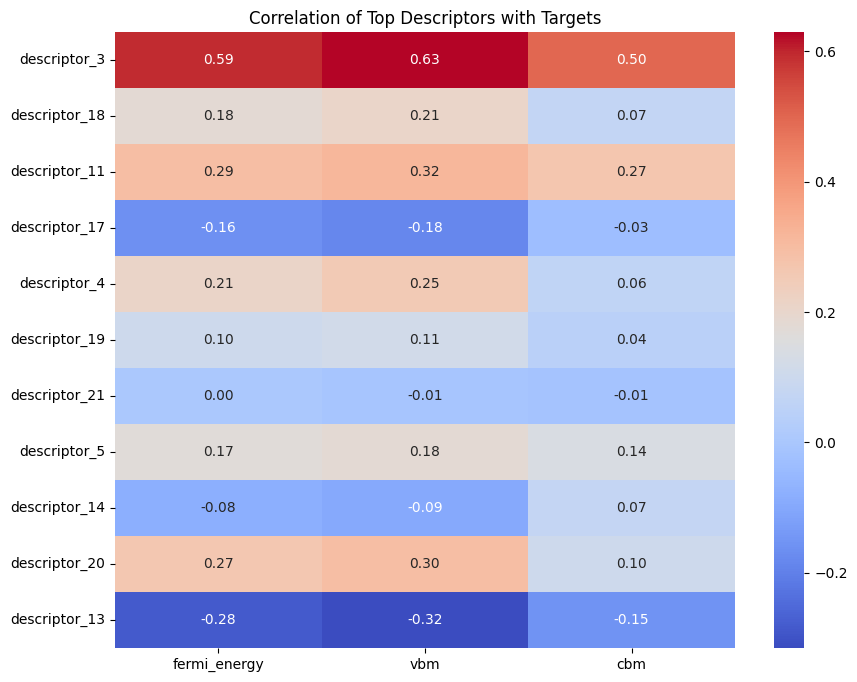

In [ ]:
# Define the top descriptors from Random Forest and XGBoost
top_rf_descriptors = ["descriptor_3","descriptor_13","descriptor_11","descriptor_20","descriptor_5","descriptor_4","descriptor_17","descriptor_14","descriptor_19","descriptor_21"]
top_xg_descriptors = ["descriptor_3","descriptor_13","descriptor_11","descriptor_20","descriptor_4","descriptor_17","descriptor_18","descriptor_5","descriptor_14","descriptor_19"]

# Combine unique descriptors from both models
top_descriptors = list(set(top_rf_descriptors + top_xg_descriptors))

# Select the top descriptors and target variables
df_top = df[top_descriptors + ["fermi_energy","vbm","cbm"]]

# Compute correlation matrix
correlation_matrix = df_top.corr()

# Extract correlation of descriptors with target variables
correlation_with_target = correlation_matrix[["fermi_energy","vbm","cbm"]].loc[top_descriptors]

# Display the correlation
print(correlation_with_target)

# Optional: Visualize the correlation matrix
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_with_target, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Top Descriptors with Targets")
plt.show()


# DATA PROCESSING FOR HYPERPARAMETER TUNNING

In [ ]:
datax = df.drop('fermi_energy', axis=1)
datax = datax.drop('vbm', axis=1)
datax = datax.drop('cbm', axis=1)

In [ ]:
datax.head()

,descriptor_1,descriptor_2,descriptor_3,descriptor_4,descriptor_5,descriptor_6,descriptor_7,descriptor_8,descriptor_9,descriptor_10,...,descriptor_15,descriptor_16,descriptor_17,descriptor_18,descriptor_19,descriptor_20,descriptor_21,descriptor_22,descriptor_23,descriptor_24
0,226.839615,12,8.161256,41.0,0.0,1.45,0.000000e+00,13.666667,0.942809,0.577578,...,0,2.18,0.000000e+00,54.00000,0.000000e+00,2750.0,0.000000e+00,3.037563,0.234792,1
3,199.450061,12,1.598453,8.0,0.0,0.60,1.110223e-16,17.500000,1.118034,0.180517,...,0,1.52,2.220446e-16,0.02658,3.469447e-18,54.8,7.105427e-15,3.188103,0.908462,1
4,159.269552,10,1.668092,8.0,0.0,0.60,1.110223e-16,14.600000,1.200000,0.236204,...,0,1.52,0.000000e+00,0.02658,0.000000e+00,54.8,0.000000e+00,2.975312,0.906406,1
6,1547.569426,80,1.030997,6.0,0.0,0.70,1.110223e-16,17.150000,3.373055,0.173869,...,0,1.70,2.220446e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,6.968453,2.772236,1
7,1190.353192,100,1.675489,6.0,0.0,0.70,2.220446e-16,17.740000,3.925863,0.185707,...,0,1.70,8.881784e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,5.097015,1.447221,1


In [ ]:

X = datax
y = df[["fermi_energy","vbm","cbm"]]  # Targets

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Random sampling for tuning
sample_fraction = 0.2
X_train_df = pd.DataFrame(X_train)
X_train_sample = X_train_df.sample(frac=sample_fraction, random_state=42)

y_train_sample = y_train.iloc[X_train_sample.index]

print(len(X_train_sample))


15459


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_train_sample, y_train_sample, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# DATA PROCESSING

In [ ]:
datax = df.drop('fermi_energy', axis=1)
datax = datax.drop('vbm', axis=1)
datax = datax.drop('cbm', axis=1)

In [ ]:
datax.head()

,descriptor_1,descriptor_2,descriptor_3,descriptor_4,descriptor_5,descriptor_6,descriptor_7,descriptor_8,descriptor_9,descriptor_10,...,descriptor_15,descriptor_16,descriptor_17,descriptor_18,descriptor_19,descriptor_20,descriptor_21,descriptor_22,descriptor_23,descriptor_24
0,226.839615,12,8.161256,41.0,0.0,1.45,0.000000e+00,13.666667,0.942809,0.577578,...,0,2.18,0.000000e+00,54.00000,0.000000e+00,2750.0,0.000000e+00,3.037563,0.234792,1
3,199.450061,12,1.598453,8.0,0.0,0.60,1.110223e-16,17.500000,1.118034,0.180517,...,0,1.52,2.220446e-16,0.02658,3.469447e-18,54.8,7.105427e-15,3.188103,0.908462,1
4,159.269552,10,1.668092,8.0,0.0,0.60,1.110223e-16,14.600000,1.200000,0.236204,...,0,1.52,0.000000e+00,0.02658,0.000000e+00,54.8,0.000000e+00,2.975312,0.906406,1
6,1547.569426,80,1.030997,6.0,0.0,0.70,1.110223e-16,17.150000,3.373055,0.173869,...,0,1.70,2.220446e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,6.968453,2.772236,1
7,1190.353192,100,1.675489,6.0,0.0,0.70,2.220446e-16,17.740000,3.925863,0.185707,...,0,1.70,8.881784e-16,140.00000,0.000000e+00,3800.0,0.000000e+00,5.097015,1.447221,1


In [ ]:

X = datax
y = df[["fermi_energy","vbm","cbm"]]  # Targets

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
joblib.dump(scaler,"ft2scaler.pkl")

['ft2scaler.pkl']

# RFR MODEL TRAINNG


In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],  # Number of trees in the forest
    "max_depth": [None, 10, 20, 30],  # Maximum depth of each tree
    "min_samples_split": [2, 5, 10],  # Minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4],  # Minimum samples required in a leaf
    "bootstrap": [True, False],  # Whether bootstrap samples are used
}

# RandomizedSearchCV to find the best hyperparameters
rfr = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=rfr, param_distributions=param_grid,
                                   n_iter=100, cv=5, verbose=1, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# Best model
best_rfr = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

# Training the best model
best_rfr.fit(X_train, y_train)

# Predictions
y_pred = best_rfr.predict(X_test)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30, 'bootstrap': True}


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")


Mean Squared Error: 1.2205357213675059
R^2 Score: 0.761108896074771


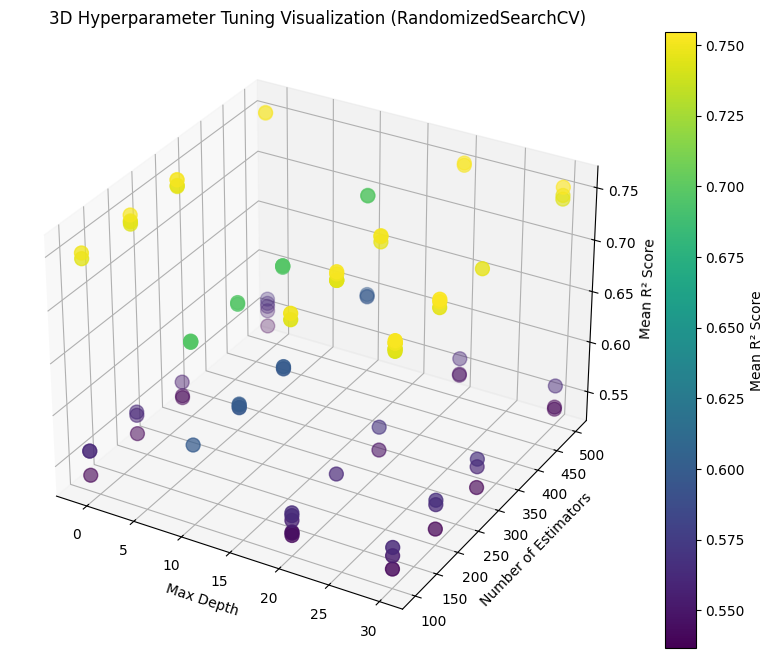

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Extract results from RandomizedSearchCV
cv_results = random_search.cv_results_

# Get parameter values and corresponding mean test scores
n_estimators = [params['n_estimators'] for params in cv_results['params']]
max_depth = [params['max_depth'] if params['max_depth'] is not None else -1 for params in cv_results['params']]  # Use -1 for None
mean_scores = cv_results['mean_test_score']  # Mean cross-validated score for each combination

# Convert to NumPy arrays for easier plotting
n_estimators = np.array(n_estimators)
max_depth = np.array(max_depth)
mean_scores = np.array(mean_scores)

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
scatter = ax.scatter(max_depth, n_estimators, mean_scores, c=mean_scores, cmap='viridis', s=100)

# Add labels and color bar
ax.set_xlabel('Max Depth')
ax.set_ylabel('Number of Estimators')
ax.set_zlabel('Mean R² Score')
ax.set_title('3D Hyperparameter Tuning Visualization (RandomizedSearchCV)')
fig.colorbar(scatter, ax=ax, label='Mean R² Score')

plt.show()


In [ ]:
# Cross-validation scores for robustness
cv_scores = cross_val_score(best_rfr, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R² Score: {np.mean(cv_scores):.4f}")

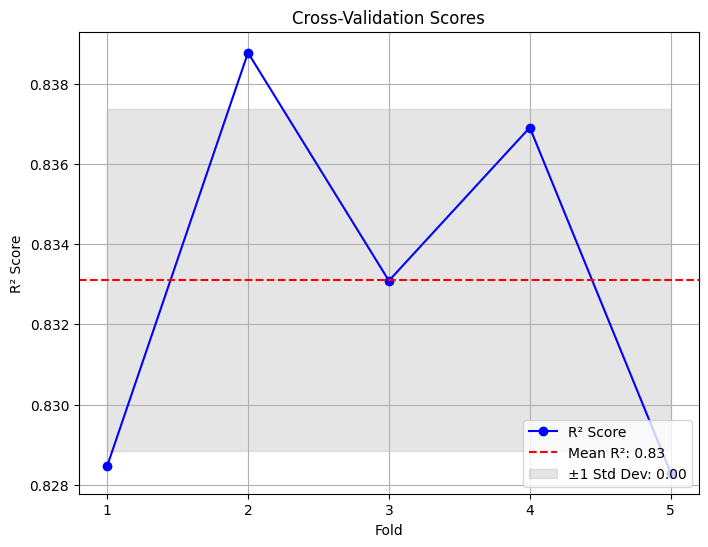

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import matplotlib.pyplot as plt

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(rfr, X_train, y_train, cv=cv, scoring='r2')

# Visualization of Cross-Validation Scores
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', linestyle='-', color='b', label='R² Score')
plt.axhline(np.mean(cv_scores), color='r', linestyle='--', label=f'Mean R²: {np.mean(cv_scores):.2f}')
plt.fill_between(range(1, len(cv_scores) + 1),
                 np.mean(cv_scores) - np.std(cv_scores),
                 np.mean(cv_scores) + np.std(cv_scores),
                 color='gray', alpha=0.2, label=f'±1 Std Dev: {np.std(cv_scores):.2f}')

plt.title('Cross-Validation Scores')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.xticks(range(1, len(cv_scores) + 1))
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
# Best parameters from RandomizedSearchCV
best_params = {
    'n_estimators': 500,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_depth': 30,
    'bootstrap': True
}

# Initialize the RandomForestRegressor with the best parameters
best_rfr = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_depth=best_params['max_depth'],
    bootstrap=best_params['bootstrap'],
    random_state=42
)


In [ ]:
type(best_rfr)

sklearn.ensemble._forest.RandomForestRegressor

In [ ]:
best_rfr = joblib.load("random_forest_model.pkl")

In [ ]:
# Train the model with the entire training dataset
best_rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=30, n_estimators=500, random_state=42)

In [ ]:
y_train_pred = best_rfr.predict(X_train)
mse = mean_squared_error(y_train,y_train_pred)
r2 = r2_score(y_train,y_train_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.11891066845485981
R^2 Score: 0.9783150049379316


In [ ]:
new_test_x = np.concatenate([X_train[:7000],X_test[:3000]],axis=0)
new_test_y = np.concatenate([y_train[:7000],y_test[:3000]],axis=0)

In [ ]:
print(len(new_test_x))
print(len(new_test_y))

10000
10000


In [ ]:
# Make predictions on the test data
y_pred = best_rfr.predict(new_test_x)

# Evaluate the model
mse = mean_squared_error(new_test_y, y_pred)
r2 = r2_score(new_test_y, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.3401751649848159
R^2 Score: 0.9400478590322354


In [ ]:

# R² Scores
mset = mean_squared_error(y_train,y_train_pred, multioutput='raw_values')
r2t = r2_score(y_train,y_train_pred, multioutput='raw_values')
print("R² Scores:", r2t)
print("mse Score",mset)

R² Scores: [0.97452683 0.98496553 0.97545266]
mse Score [0.14670203 0.08490493 0.12512504]


In [ ]:

# R² Scores
mse = mean_squared_error(new_test_y, y_pred, multioutput='raw_values')
r2 = r2_score(new_test_y, y_pred, multioutput='raw_values')
print("R² Scores:", r2)
print("mse Score",mse)

R² Scores: [0.9311572  0.95687367 0.93211271]
mse Score [0.41204363 0.2521363  0.35634556]


In [ ]:
# Print metrics
target_names = ["fermi_energy","vbm","cbm"]
for i, target in enumerate(target_names):
    print(f"{target}:")
    print(f"  Mean Squared Error (MSE): {mse[i]:.4f}")
    print(f"  R² Score: {r2[i]:.4f}")

fermi_energy:
  Mean Squared Error (MSE): 0.4120
  R² Score: 0.9312
vbm:
  Mean Squared Error (MSE): 0.2521
  R² Score: 0.9569
cbm:
  Mean Squared Error (MSE): 0.3563
  R² Score: 0.9321


In [ ]:
target_names = ["fermi_energy","vbm","cbm"]
for i, target in enumerate(target_names):
    print(f"{target}:")
    print(f"  Mean Squared Error (MSE): {mset[i]:.4f}")
    print(f"  R² Score: {r2t[i]:.4f}")

fermi_energy:
  Mean Squared Error (MSE): 0.1467
  R² Score: 0.9745
vbm:
  Mean Squared Error (MSE): 0.0849
  R² Score: 0.9850
cbm:
  Mean Squared Error (MSE): 0.1251
  R² Score: 0.9755


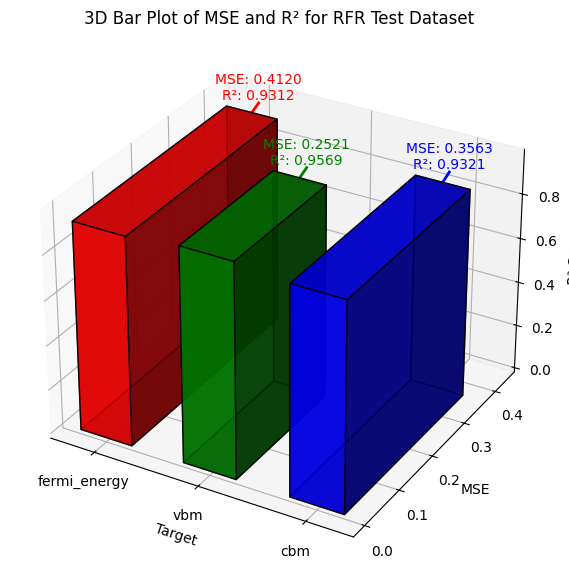

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # Enable 3D plotting

# Given data for the three targets
target_names = ["fermi_energy", "vbm", "cbm"]

# Define a unique color for each target
colors = ['red', 'green', 'blue']

x_positions = np.arange(len(target_names))

dx = 0.5


dy_values = mse
dz_values = r2


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


for i in range(len(target_names)):
    # Plot the 3D bar for the target
    ax.bar3d(x_positions[i], 0, 0,
             dx, dy_values[i], dz_values[i],
             color=colors[i], alpha=0.8, edgecolor='k')


    x_top = x_positions[i] + dx/2
    y_top = dy_values[i]
    z_top = dz_values[i]


    offset_y = 0.02  # adjust as needed
    offset_z = 0.02  # adjust as needed

    annotation = f"MSE: {mse[i]:.4f}\nR²: {r2[i]:.4f}"


    text_x = x_top
    text_y = y_top + offset_y
    text_z = z_top + offset_z

    ax.text(text_x, text_y, text_z, annotation,
            color=colors[i], fontsize=10, ha='center', va='bottom')


    line_x = [text_x, x_top]
    line_y = [text_y, y_top]
    line_z = [text_z, z_top]

    ax.plot(line_x, line_y, line_z, color=colors[i], linewidth=2)

# Label the axes
ax.set_xlabel("Target")
ax.set_ylabel("MSE")
ax.set_zlabel("R² Score")

ax.set_xticks(x_positions + dx/2)
ax.set_xticklabels(target_names)

plt.title("3D Bar Plot of MSE and R² for RFR Test Dataset")
plt.show()


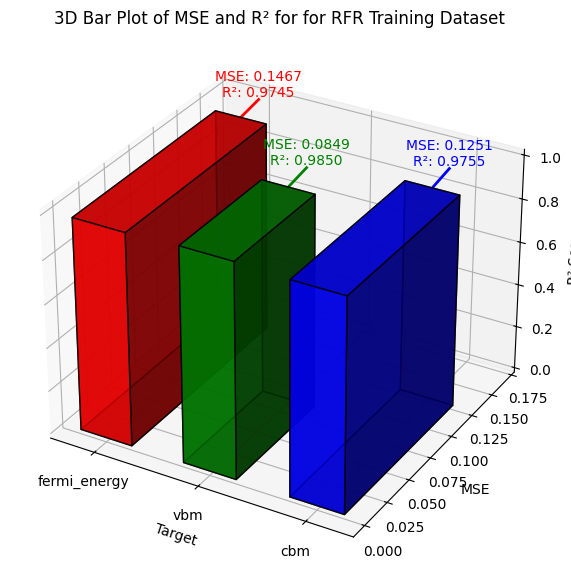

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # Enable 3D plotting

# Given data for the three targets
target_names = ["fermi_energy", "vbm", "cbm"]

# Define a unique color for each target
colors = ['red', 'green', 'blue']

x_positions = np.arange(len(target_names))

dx = 0.5


dy_values = mset
dz_values = r2t


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


for i in range(len(target_names)):
    # Plot the 3D bar for the target
    ax.bar3d(x_positions[i], 0, 0,
             dx, dy_values[i], dz_values[i],
             color=colors[i], alpha=0.8, edgecolor='k')


    x_top = x_positions[i] + dx/2
    y_top = dy_values[i]
    z_top = dz_values[i]


    offset_y = 0.02  # adjust as needed
    offset_z = 0.02  # adjust as needed

    annotation = f"MSE: {mset[i]:.4f}\nR²: {r2t[i]:.4f}"


    text_x = x_top
    text_y = y_top + offset_y
    text_z = z_top + offset_z

    ax.text(text_x, text_y, text_z, annotation,
            color=colors[i], fontsize=10, ha='center', va='bottom')


    line_x = [text_x, x_top]
    line_y = [text_y, y_top]
    line_z = [text_z, z_top]

    ax.plot(line_x, line_y, line_z, color=colors[i], linewidth=2)

# Label the axes
ax.set_xlabel("Target")
ax.set_ylabel("MSE")
ax.set_zlabel("R² Score")

ax.set_xticks(x_positions + dx/2)
ax.set_xticklabels(target_names)

plt.title("3D Bar Plot of MSE and R² for for RFR Training Dataset")
plt.show()


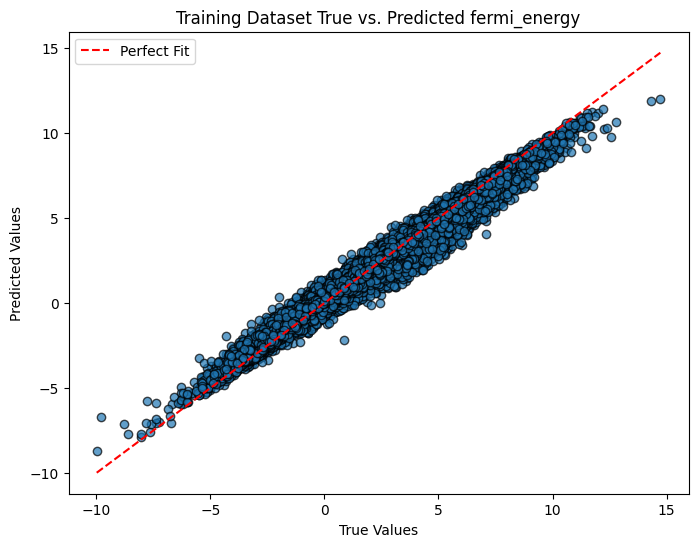

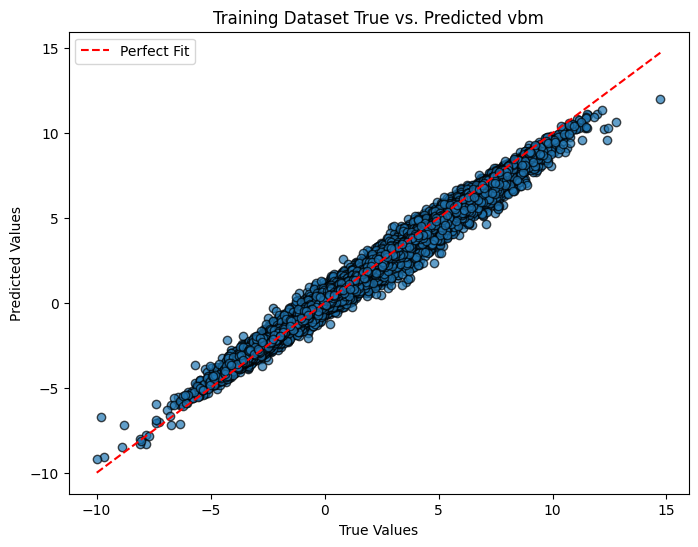

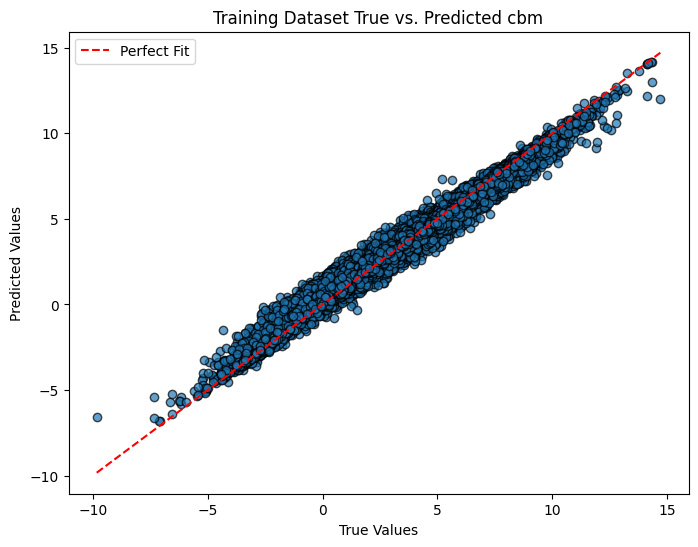

In [ ]:
# Visualization: True vs Predicted for each target
for i, target in enumerate(target_names):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_train.iloc[:, i], y_train_pred[:, i], alpha=0.7, edgecolor='k')
    plt.plot([y_train.iloc[:, i].min(), y_train.iloc[:, i].max()],
             [y_train.iloc[:, i].min(), y_train.iloc[:, i].max()],
             color='r', linestyle='--', label="Perfect Fit")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Training Dataset True vs. Predicted {target}")
    plt.legend()
    plt.show()

In [ ]:
y_test = new_test_y
y_test = pd.DataFrame(y_test, columns=target_names)
print(new_test_y[0],y_pred[0])

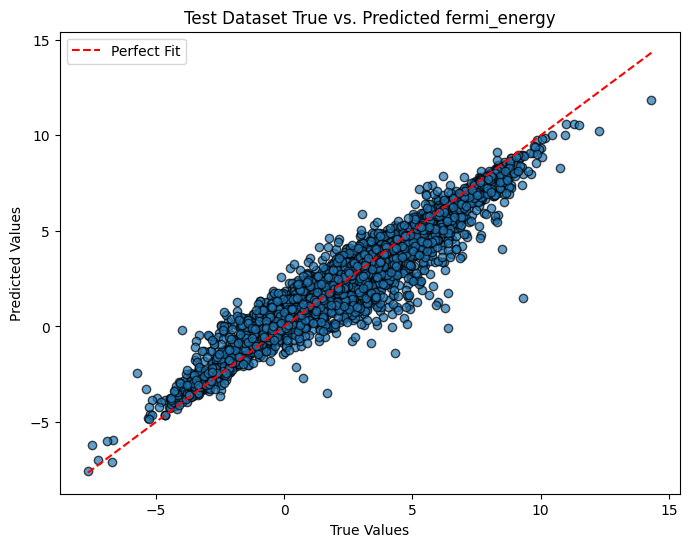

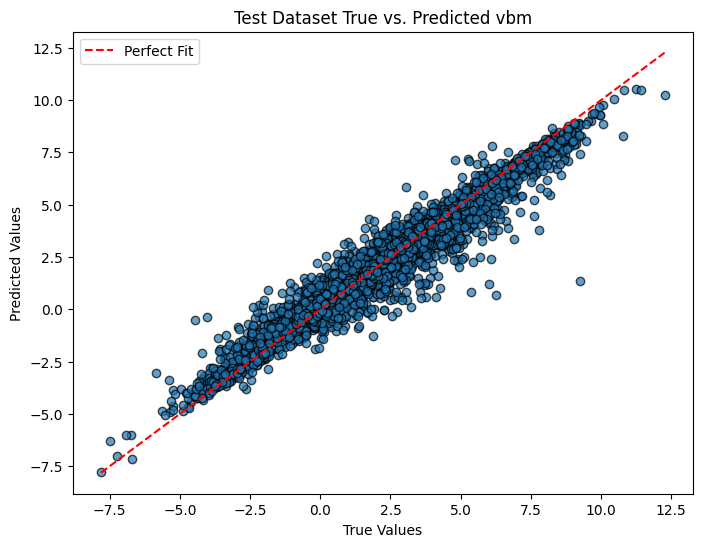

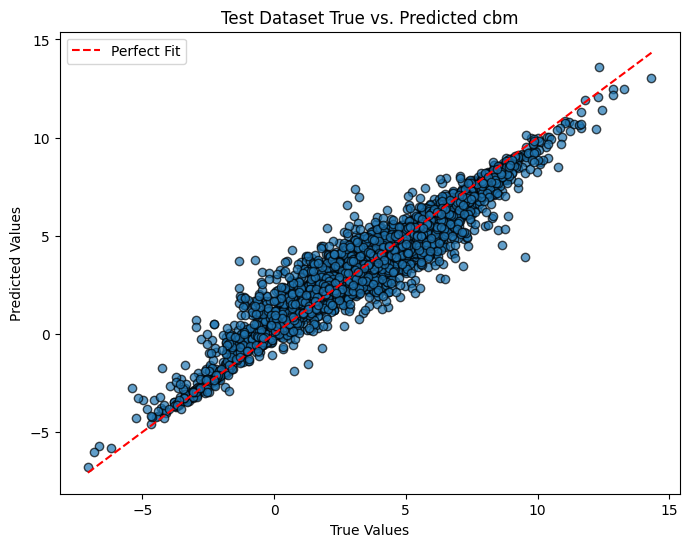

In [ ]:
# Visualization: True vs Predicted for each target
for i, target in enumerate(target_names):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test.iloc[:, i], y_pred[:, i], alpha=0.7, edgecolor='k')
    plt.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
             [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
             color='r', linestyle='--', label="Perfect Fit")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Test Dataset True vs. Predicted {target}")
    plt.legend()
    plt.show()

In [ ]:
import joblib

# Save the trained model to a file
joblib.dump(best_rfr, "random_forest_model.pkl")
print("Model saved successfully!")


Model saved successfully!


# XGB MODEL TRAINNG


In [ ]:
xgb_param_grid = {
    'estimator__n_estimators': [100, 200, 300, 500],
    'estimator__max_depth': [3, 5, 7, 9],
    'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__subsample': [0.6, 0.8, 1.0],
    'estimator__colsample_bytree': [0.6, 0.8, 1.0],
    'estimator__gamma': [0, 0.1, 0.2, 0.3],
    'estimator__reg_alpha': [0, 0.1, 0.5, 1],
    'estimator__reg_lambda': [0, 0.1, 0.5, 1]
}

# Initialize XGBoost regressor
xgb = XGBRegressor(objective='reg:squarederror',
                   random_state=42,
                   n_jobs=-1)

# Wrap XGBoost with MultiOutputRegressor
multi_output_xgb = MultiOutputRegressor(xgb)

# Randomized search with same settings as RFR
xgb_random_search = RandomizedSearchCV(
    estimator=multi_output_xgb,
    param_distributions=xgb_param_grid,
    n_iter=100,  # Same number of iterations
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit to training data
xgb_random_search.fit(X_train, y_train)

# Get best estimator
best_xgb = xgb_random_search.best_estimator_
print("Best XGBoost Parameters:", xgb_random_search.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best XGBoost Parameters: {'estimator__subsample': 0.6, 'estimator__reg_lambda': 0.1, 'estimator__reg_alpha': 1, 'estimator__n_estimators': 300, 'estimator__max_depth': 9, 'estimator__learning_rate': 0.05, 'estimator__gamma': 0.1, 'estimator__colsample_bytree': 1.0}


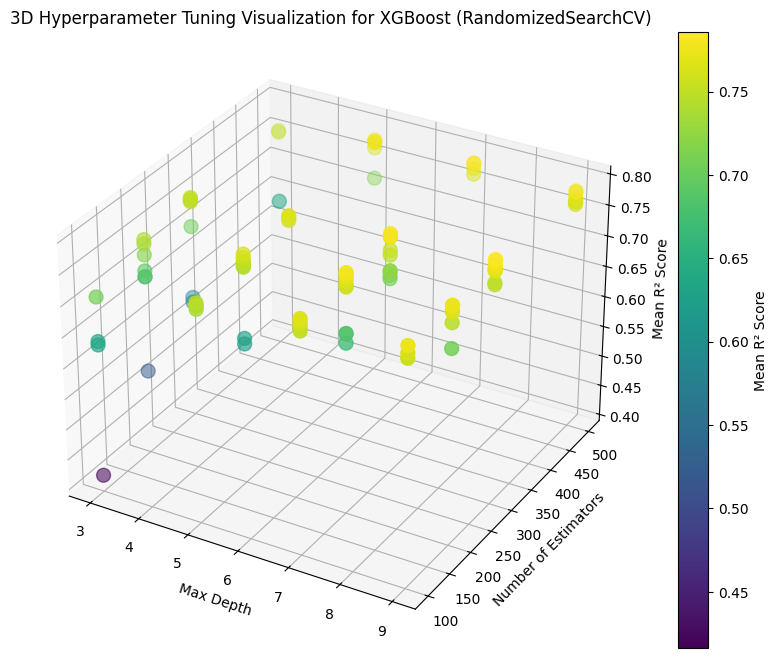

In [ ]:
# Extract results from RandomizedSearchCV
cv_results = xgb_random_search.cv_results_

# Get parameter values and corresponding mean test scores
n_estimators = [params['estimator__n_estimators'] for params in cv_results['params']]
max_depth = [params['estimator__max_depth'] for params in cv_results['params']]
mean_scores = cv_results['mean_test_score']  # Mean cross-validated score for each combination

# Convert to NumPy arrays for easier plotting
n_estimators = np.array(n_estimators)
max_depth = np.array(max_depth)
mean_scores = np.array(mean_scores)

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
scatter = ax.scatter(max_depth, n_estimators, mean_scores, c=mean_scores, cmap='viridis', s=100)

# Add labels and color bar
ax.set_xlabel('Max Depth')
ax.set_ylabel('Number of Estimators')
ax.set_zlabel('Mean R² Score')
ax.set_title('3D Hyperparameter Tuning Visualization for XGBoost (RandomizedSearchCV)')
fig.colorbar(scatter, ax=ax, label='Mean R² Score')

plt.show()

In [ ]:
# Cross-validation scores for robustness
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R² Score: {np.mean(cv_scores):.4f}")

Cross-Validation R² Scores: [0.780366   0.7931518  0.7774232  0.78871322 0.78879976]
Mean R² Score: 0.7857


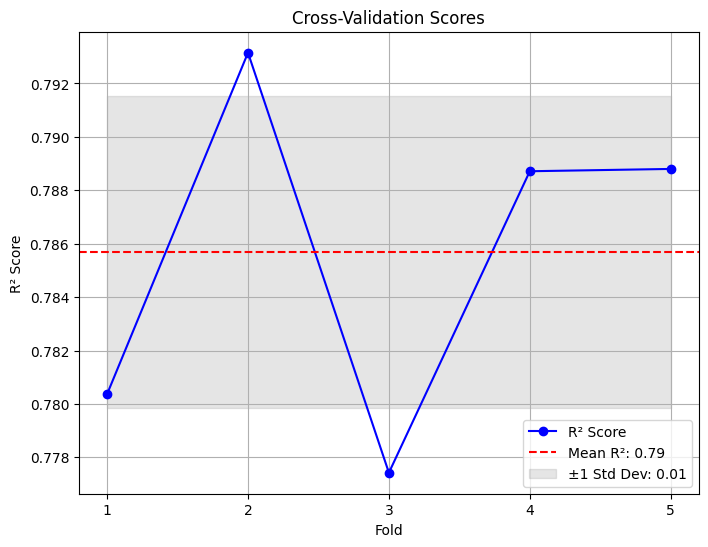

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Visualization of Cross-Validation Scores
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', linestyle='-', color='b', label='R² Score')
plt.axhline(np.mean(cv_scores), color='r', linestyle='--', label=f'Mean R²: {np.mean(cv_scores):.2f}')
plt.fill_between(range(1, len(cv_scores) + 1),
                 np.mean(cv_scores) - np.std(cv_scores),
                 np.mean(cv_scores) + np.std(cv_scores),
                 color='gray', alpha=0.2, label=f'±1 Std Dev: {np.std(cv_scores):.2f}')

plt.title('Cross-Validation Scores')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.xticks(range(1, len(cv_scores) + 1))
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    subsample=0.8,
    reg_lambda=0.1,
    reg_alpha=0.05,
    n_estimators=1000,
    max_depth=9,
    learning_rate=0.2,
    gamma=0.4,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)


In [ ]:
xgb_model = joblib.load("XGBoost.pkl")

In [ ]:
# Fitting the model
xgb_model.fit(X_train, y_train)

In [ ]:
len(y_train)

77296

In [ ]:
new_test_x = np.concatenate([X_train[:7000],X_test[:3000]],axis=0)
new_test_y = np.concatenate([y_train[:7000],y_test[:3000]],axis=0)
X_test = new_test_x
y_test = new_test_y

In [ ]:
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Squared Error (MSE): 0.30724391833661796
R2 Score: 0.9459883023220192


In [ ]:
y_train_pred = xgb_model.predict(X_train)
mse = mean_squared_error(y_train,y_train_pred)
r2 = r2_score(y_train,y_train_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.10109331458806992
R^2 Score: 0.9815816283226013


In [ ]:
# Make predictions on the test data
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.30724391833661796
R^2 Score: 0.9459883023220192


In [ ]:
R² Scores
mset = mean_squared_error(y_train,y_train_pred, multioutput='raw_values')
r2t = r2_score(y_train,y_train_pred, multioutput='raw_values')
print("R² Scores:", r2t)
print("mse Score",mset)


In [ ]:
# R² Scores
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("R² Scores:", r2)
print("mse Score",mse)

R² Scores: [0.93712652 0.95830251 0.94253588]
mse Score [0.37631555 0.24378262 0.30163358]


In [ ]:
# Print metrics
target_names = ["fermi_energy","vbm","cbm"]
for i, target in enumerate(target_names):
    print(f"{target}:")
    print(f"  Mean Squared Error (MSE): {mse[i]:.4f}")
    print(f"  R² Score: {r2[i]:.4f}")

fermi_energy:
  Mean Squared Error (MSE): 0.3763
  R² Score: 0.9371
vbm:
  Mean Squared Error (MSE): 0.2438
  R² Score: 0.9583
cbm:
  Mean Squared Error (MSE): 0.3016
  R² Score: 0.9425


In [ ]:
for i, target in enumerate(target_names):
    print(f"{target}:")
    print(f"  Mean Squared Error (MSE): {mset[i]:.4f}")
    print(f"  R² Score: {r2t[i]:.4f}")

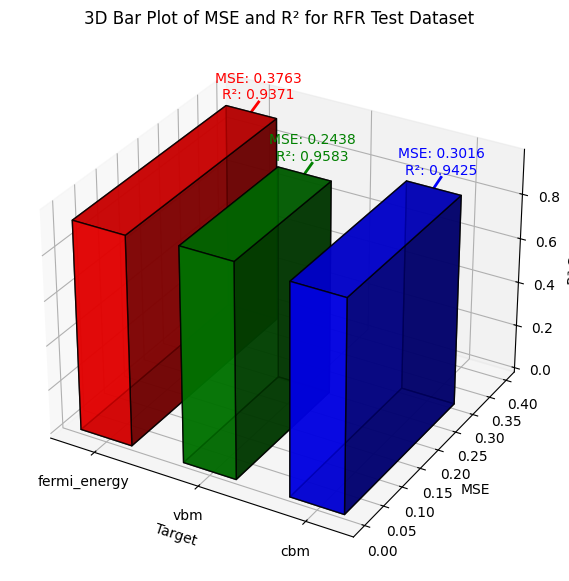

In [ ]:
# Given data for the three targets
target_names = ["fermi_energy", "vbm", "cbm"]

# Define a unique color for each target
colors = ['red', 'green', 'blue']

x_positions = np.arange(len(target_names))

dx = 0.5


dy_values = mse
dz_values = r2


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


for i in range(len(target_names)):
    # Plot the 3D bar for the target
    ax.bar3d(x_positions[i], 0, 0,
             dx, dy_values[i], dz_values[i],
             color=colors[i], alpha=0.8, edgecolor='k')


    x_top = x_positions[i] + dx/2
    y_top = dy_values[i]
    z_top = dz_values[i]


    offset_y = 0.02  # adjust as needed
    offset_z = 0.02  # adjust as needed

    annotation = f"MSE: {mse[i]:.4f}\nR²: {r2[i]:.4f}"


    text_x = x_top
    text_y = y_top + offset_y
    text_z = z_top + offset_z

    ax.text(text_x, text_y, text_z, annotation,
            color=colors[i], fontsize=10, ha='center', va='bottom')


    line_x = [text_x, x_top]
    line_y = [text_y, y_top]
    line_z = [text_z, z_top]

    ax.plot(line_x, line_y, line_z, color=colors[i], linewidth=2)

# Label the axes
ax.set_xlabel("Target")
ax.set_ylabel("MSE")
ax.set_zlabel("R² Score")

ax.set_xticks(x_positions + dx/2)
ax.set_xticklabels(target_names)

plt.title("3D Bar Plot of MSE and R² for RFR Test Dataset")
plt.show()


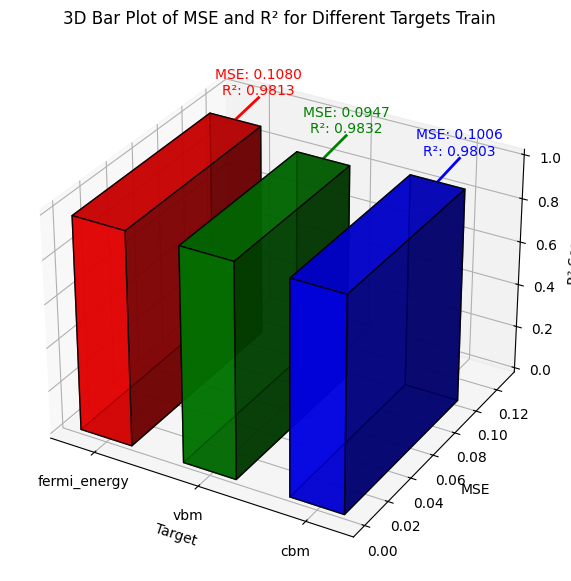

In [ ]:
# Given data for the three targets
target_names = ["fermi_energy", "vbm", "cbm"]

# Define a unique color for each target
colors = ['red', 'green', 'blue']

x_positions = np.arange(len(target_names))

dx = 0.5


dy_values = mset
dz_values = r2t


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


for i in range(len(target_names)):
    # Plot the 3D bar for the target
    ax.bar3d(x_positions[i], 0, 0,
             dx, dy_values[i], dz_values[i],
             color=colors[i], alpha=0.8, edgecolor='k')


    x_top = x_positions[i] + dx/2
    y_top = dy_values[i]
    z_top = dz_values[i]


    offset_y = 0.02  # adjust as needed
    offset_z = 0.02  # adjust as needed

    annotation = f"MSE: {mset[i]:.4f}\nR²: {r2t[i]:.4f}"


    text_x = x_top
    text_y = y_top + offset_y
    text_z = z_top + offset_z

    ax.text(text_x, text_y, text_z, annotation,
            color=colors[i], fontsize=10, ha='center', va='bottom')


    line_x = [text_x, x_top]
    line_y = [text_y, y_top]
    line_z = [text_z, z_top]

    ax.plot(line_x, line_y, line_z, color=colors[i], linewidth=2)

# Label the axes
ax.set_xlabel("Target")
ax.set_ylabel("MSE")
ax.set_zlabel("R² Score")

ax.set_xticks(x_positions + dx/2)
ax.set_xticklabels(target_names)

plt.title("3D Bar Plot of MSE and R² for Different Targets Train")
plt.show()


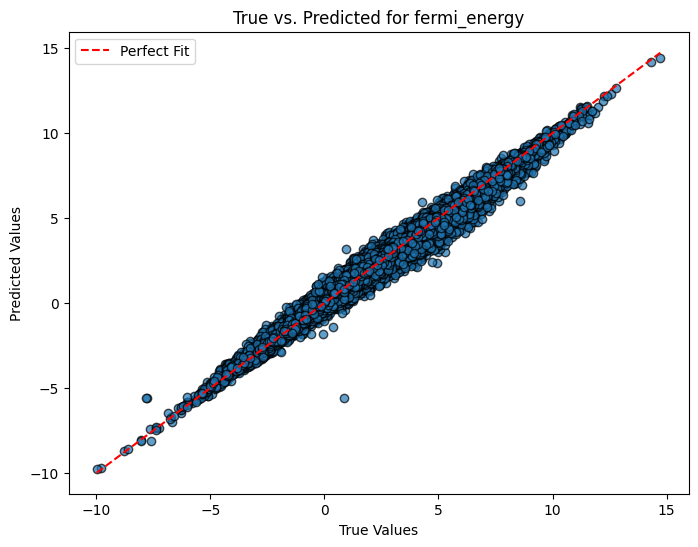

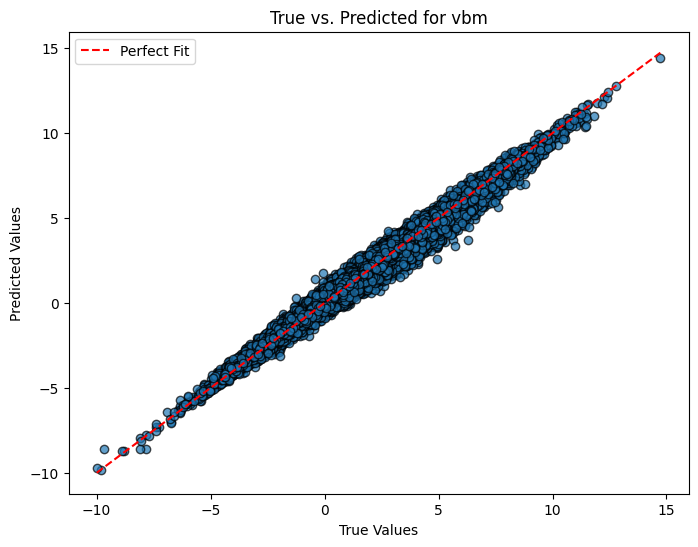

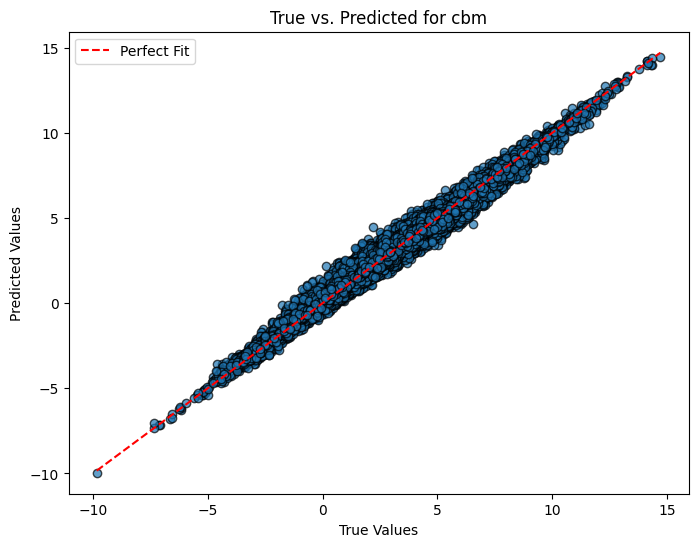

In [ ]:
# Visualization: True vs Predicted for each target
for i, target in enumerate(target_names):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_train.iloc[:, i], y_train_pred[:, i], alpha=0.7, edgecolor='k')
    plt.plot([y_train.iloc[:, i].min(), y_train.iloc[:, i].max()],
             [y_train.iloc[:, i].min(), y_train.iloc[:, i].max()],
             color='r', linestyle='--', label="Perfect Fit")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"True vs. Predicted for {target}")
    plt.legend()
    plt.show()

In [ ]:
y_test = new_test_y
y_test = pd.DataFrame(y_test, columns=target_names)
print(new_test_y[0],y_pred[0])

[5.1452451 4.8324    6.2524   ] [5.161335  5.0940185 6.540567 ]


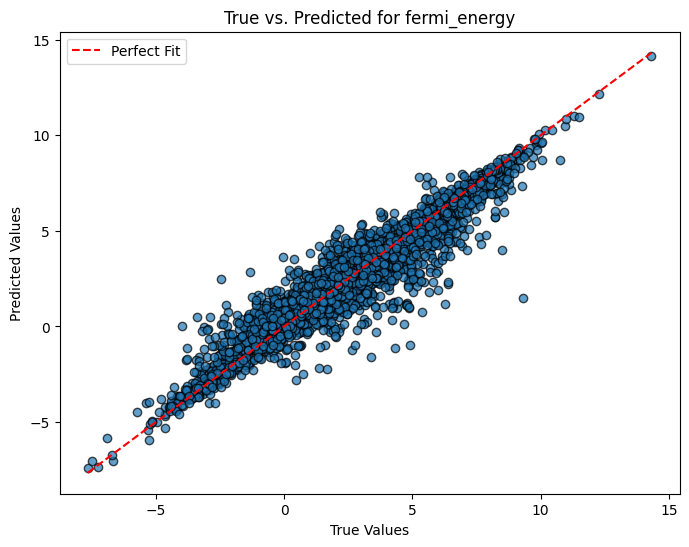

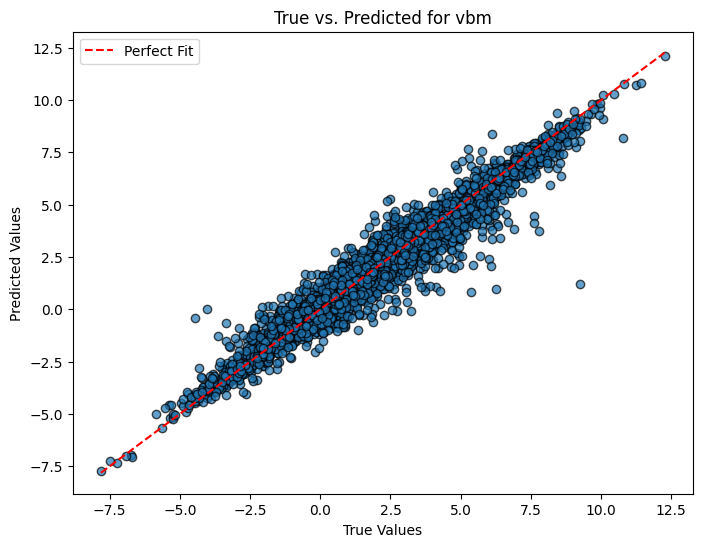

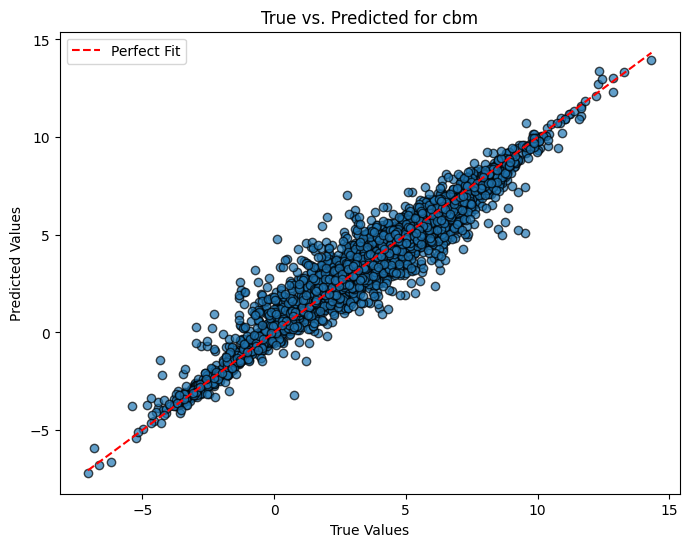

In [ ]:
# Visualization: True vs Predicted for each target
for i, target in enumerate(target_names):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test.iloc[:, i], y_pred[:, i], alpha=0.7, edgecolor='k')
    plt.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
             [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
             color='r', linestyle='--', label="Perfect Fit")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"True vs. Predicted for {target}")
    plt.legend()
    plt.show()

In [ ]:
# Save the trained model to a file
joblib.dump(xgb_model, "XGBoost.pkl")
print("Model saved successfully!")

Model saved successfully!


# OLD ML TRAINING



In [ ]:
"""X_train_scaled.to_csv("/content/gdrive/MyDrive/Descriptor/data_frame/X_train_scaled.csv")
X_test_scaled.to_csv("/content/gdrive/MyDrive/Descriptor/data_frame/X_test_scaled.csv")
y_train.to_csv("/content/gdrive/MyDrive/Descriptor/data_frame/y_train.csv")
y_test.to_csv("/content/gdrive/MyDrive/Descriptor/data_frame/y_test.csv")"""

In [ ]:
""", 'SVR'
   SVR(kernel='rbf', epsilon=0.1),"""

In [ ]:
regr_names = ['XGBoostR', 'RFR']
regr_objects = [
    XGBRegressor(objective='reg:linear', colsample_bytree=0.3, learning_rate=0.1,
                  max_depth=400, alpha=10, n_estimators=400),
    RandomForestRegressor(n_estimators=400, max_depth=400, random_state=0),
]

In [ ]:
ele = ['O']

In [ ]:
"""'SVC'
,
    SVC(kernel='rbf', gamma='auto'),
"""


In [ ]:
regr_names2 = ['XGBoostC', 'RFC']
regr_objects2 = [
    XGBClassifier(objective='binary:logistic', colsample_bytree=0.3, learning_rate=0.1,
                   max_depth=400, alpha=10, n_estimators=400),
    RandomForestClassifier(n_estimators=400, max_depth=400, random_state=0)]

In [ ]:
for regr_choice in range(2):
    regr = regr_objects2[regr_choice]
    regr_name = regr_names2[regr_choice]
    regr.fit(X_train_scaled, y_train)

   #1 afasdfasfdasfdasfdasfd
    y_predicted = regr.predict(X_train_scaled)

    errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/train_'+regr_name+'.txt', 'w')
    errors_file.write(
        'accuracy\t'+str(accuracy_score(y_train, y_predicted))+'\n')
    errors_file.write('precision\t'+str(precision_score(y_train, y_predicted))+'\n')
    errors_file.close()

    xPlot = y_train
    yPlot = y_predicted
    plt.figure(figsize=(10, 10))
    plt.plot(xPlot, yPlot, 'ro')
    plt.plot(xPlot, xPlot)
    plt.ylabel(regr_name)
    plt.xlabel('DFT')
    plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'_train', bbox_inches='tight')



    #2 ajfdskaskjfdakjshfdkjaskfdaksfdlk
    y_predicted = regr.predict(X_test_scaled)

    errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/test_'+regr_name+'.txt', 'w')
    errors_file.write(
        'accuracy\t'+str(accuracy_score(y_test, y_predicted))+'\n')
    errors_file.write('precision\t'+str(precision_score(y_test, y_predicted))+'\n')
    errors_file.close()

    xPlot = y_test
    yPlot = y_predicted
    plt.figure(figsize=(10, 10))
    plt.plot(xPlot, yPlot, 'ro')
    plt.plot(xPlot, xPlot)
    plt.ylabel(regr_name)
    plt.xlabel('DFT')
    plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'_test', bbox_inches='tight')


    #3 ajkfdhsfdkjsakjhfdkajshkfdjhaksjfdla
    y_predicted = regr.predict(oxy_x)

    errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/oxygen_'+regr_name+'.txt', 'w')
    errors_file.write(
        'accuracy\t'+str(accuracy_score(oxy_y, y_predicted))+'\n')
    errors_file.write('precision\t'+str(precision_score(oxy_y, y_predicted))+'\n')
    errors_file.close()

    xPlot = oxy_y
    yPlot = y_predicted
    plt.figure(figsize=(10, 10))
    plt.plot(xPlot, yPlot, 'ro')
    plt.plot(xPlot, xPlot)
    plt.ylabel(regr_name)
    plt.xlabel('DFT')
    plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'_oxygen', bbox_inches='tight')


    #4 ajfkakjsfljaskfdjhaksjhfdkasdf
    y_predicted = regr.predict(no_oxy_x)

    errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/no_oxygen_'+regr_name+'.txt', 'w')
    errors_file.write(
        'accuracy\t'+str(accuracy_score(no_oxy_y, y_predicted))+'\n')
    errors_file.write('precision\t'+str(precision_score(no_oxy_y, y_predicted))+'\n')
    errors_file.close()

    xPlot = no_oxy_y
    yPlot = y_predicted
    plt.figure(figsize=(10, 10))
    plt.plot(xPlot, yPlot, 'ro')
    plt.plot(xPlot, xPlot)
    plt.ylabel(regr_name)
    plt.xlabel('DFT')
    plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'_no_oxygen', bbox_inches='tight')



    #4 afdskjalsjfdlkajsldfkjlajdsflk;asd
    y_predicted = regr.predict(li_x)

    errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/Lithium_'+regr_name+'.txt', 'w')
    errors_file.write(
        'accuracy\t'+str(accuracy_score(li_y, y_predicted))+'\n')
    errors_file.write('precision\t'+str(precision_score(li_y, y_predicted))+'\n')
    errors_file.close()

    xPlot = li_y
    yPlot = y_predicted
    plt.figure(figsize=(10, 10))
    plt.plot(xPlot, yPlot, 'ro')
    plt.plot(xPlot, xPlot)
    plt.ylabel(regr_name)
    plt.xlabel('DFT')
    plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'_Lithium', bbox_inches='tight')


    #5BAUFADSFAISFIUAHSDFHAKSDKASDKJF
    y_predicted = regr.predict(mn_x)

    errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/Manganese_'+regr_name+'.txt', 'w')
    errors_file.write(
        'accuracy\t'+str(accuracy_score(mn_y, y_predicted))+'\n')
    errors_file.write('precision\t'+str(precision_score(mn_y, y_predicted))+'\n')
    errors_file.close()

    xPlot = mn_y
    yPlot = y_predicted
    plt.figure(figsize=(10, 10))
    plt.plot(xPlot, yPlot, 'ro')
    plt.plot(xPlot, xPlot)
    plt.ylabel(regr_name)
    plt.xlabel('DFT')
    plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'_Manganese', bbox_inches='tight')


    y_predicted = regr.predict(p_x)

    errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/Phosphorus_'+regr_name+'.txt', 'w')
    errors_file.write(
        'accuracy\t'+str(accuracy_score(p_y, y_predicted))+'\n')
    errors_file.write('precision\t'+str(precision_score(p_y, y_predicted))+'\n')
    errors_file.close()

    xPlot = p_y
    yPlot = y_predicted
    plt.figure(figsize=(10, 10))
    plt.plot(xPlot, yPlot, 'ro')
    plt.plot(xPlot, xPlot)
    plt.ylabel(regr_name)
    plt.xlabel('DFT')
    plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'_Phosphorus', bbox_inches='tight')


KeyboardInterrupt: ignored

In [ ]:

y_predicted = regr.predict(no_oxy_x)
print(accuracy_score(no_oxy_y,y_predicted))


0.9883601722315979


In [ ]:
y_predicted = regr.predict(X_train_scaled)
print(accuracy_score(y_train, y_predicted))
print(precision_score(y_train, y_predicted))

0.9884632128863735
0.9805259029364619


Text(0.5, 0, 'DFT')

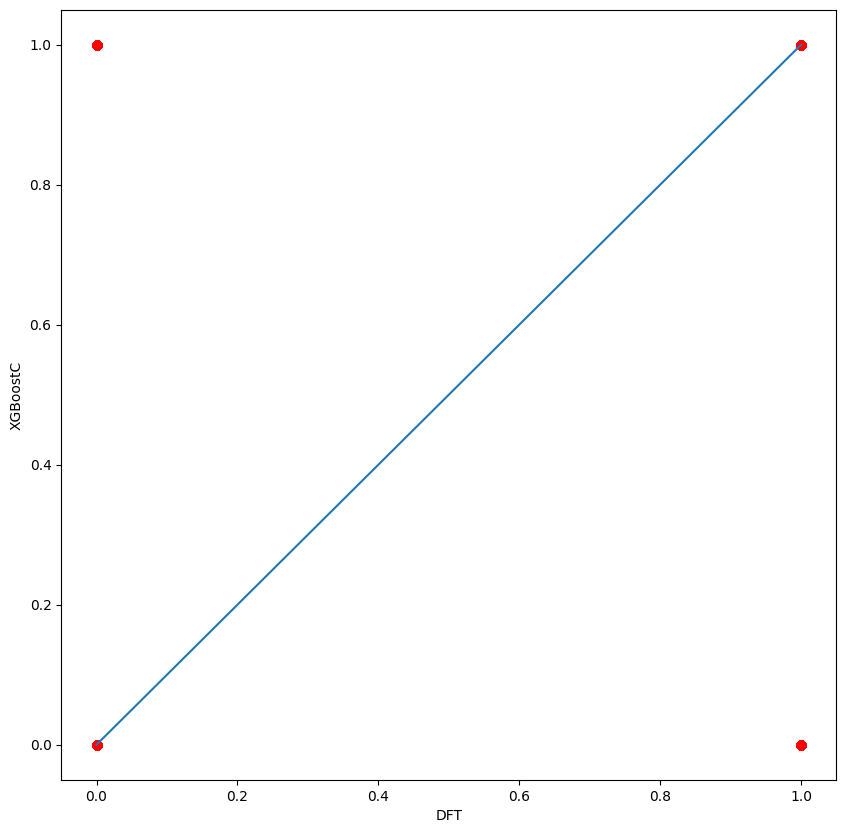

In [ ]:
xPlot = y_train
yPlot = y_predicted
plt.figure(figsize=(10, 10))
plt.plot(xPlot, yPlot, 'ro')
plt.plot(xPlot, xPlot)
plt.ylabel(regr_name)
plt.xlabel('DFT')

In [ ]:
print(str(np.sqrt(mean_squared_error(y_train, y_predicted))))

0.19681788951451706


In [ ]:
regr_name = 'SVM'
regr =  svm.SVR(kernel='rbf', epsilon=0.1, verbose=True)
regr.fit(X_train_scaled, y_train)

y_predicted = regr.predict(X_test_scaled)

print(mean_squared_error(y_test, y_predicted))
print(r2_score(y_test, y_predicted))

errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'Test_Analysis.txt', 'w')
errors_file.write('RMSE\t'+str(np.sqrt(mean_squared_error(y_test, y_predicted)))+'\n')
errors_file.write('r2\t'+str(r2_score(y_test, y_predicted))+'\n')
errors_file.close()

xPlot = y_test
yPlot = y_predicted
plt.figure(figsize=(10, 10))
plt.plot(xPlot, yPlot, 'ro')
plt.plot(xPlot, xPlot)
plt.ylabel(regr_name)
plt.xlabel('DFT')
plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'Correlation_Test', bbox_inches='tight')

y_predicted = regr.predict(X_train_scaled)

print(mean_squared_error(y_train, y_predicted))
print(r2_score(y_train, y_predicted))

errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'Train_Analysis.txt', 'w')
errors_file.write('RMSE\t'+str(np.sqrt(mean_squared_error(y_train, y_predicted)))+'\n')
errors_file.write('r2\t'+str(r2_score(y_train, y_predicted))+'\n')
errors_file.close()

xPlot = y_train
yPlot = y_predicted
plt.figure(figsize=(10, 10))
plt.plot(xPlot, yPlot, 'ro')
plt.plot(xPlot, xPlot)
plt.ylabel(regr_name)
plt.xlabel('DFT')
plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+regr_name+'Correlation_Train', bbox_inches='tight')


In [ ]:
i = 1
X_train_scaled = X_train_scaled[i].values.reshape(-1,1)
X_test_scaled = X_test_scaled[i].values.reshape(-1,1)
model = RandomForestRegressor(n_estimators=2, max_depth=100, random_state=0)

model.fit(X_train_scaled, y_train)

y_predicted = model.predict(X_test_scaled)

print(mean_squared_error(y_test, y_predicted))
print(r2_score(y_test, y_predicted))

errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/'+nu+'Test_Analysis.txt', 'w')
errors_file.write(
        'RMSE\t'+str(np.sqrt(mean_squared_error(y_test, y_predicted)))+'\n')
errors_file.write('r2\t'+str(r2_score(y_test, y_predicted))+'\n')
errors_file.close()

xPlot = y_test
yPlot = y_predicted
plt.figure(figsize=(10, 10))
plt.plot(xPlot, yPlot, 'ro')
plt.plot(xPlot, xPlot)
plt.ylabel('descriptor '+nu+'coloumn')
plt.xlabel('DFT')
plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+nu+'Correlation_Test', bbox_inches='tight')

y_predicted = model.predict(X_train_scaled)

print(mean_squared_error(y_train, y_predicted))
print(r2_score(y_train, y_predicted))

errors_file = open('/content/gdrive/MyDrive/Descriptor/data/models/'+nu+'Train_Analysis.txt', 'w')
errors_file.write(
        'RMSE\t'+str(np.sqrt(mean_squared_error(y_train, y_predicted)))+'\n')
errors_file.write('r2\t'+str(r2_score(y_train, y_predicted))+'\n')
errors_file.close()

xPlot = y_train
yPlot = y_predicted
plt.figure(figsize=(10, 10))
plt.plot(xPlot, yPlot, 'ro')
plt.plot(xPlot, xPlot)
plt.ylabel('descriptor '+nu+'coloumn')
plt.xlabel('DFT')
plt.savefig('/content/gdrive/MyDrive/Descriptor/data/models/'+nu+'Correlation_Train', bbox_inches='tight')

In [ ]:
import pandas as pd

# Define the elements to filter
elements_to_filter = ['O', 'Li', 'Mn', 'P']

# Filter the data to include only crystals containing specified elements
data_with_oxygen = datax[datax["formula"].apply(lambda formula: 'O' in formula)]
data_with_li = datax[datax["formula"].apply(lambda formula: 'Li' in formula)]
data_with_mn = datax[datax["formula"].apply(lambda formula: 'Mn' in formula)]
data_with_p = datax[datax["formula"].apply(lambda formula: 'P' in formula)]

# Filter the data to remove crystals containing specified elements
data_without_oxygen = datax[~datax["formula"].apply(lambda formula: 'O' in formula)]
data_without_specific_elements = data_without_oxygen[~data_without_oxygen["formula"].apply(lambda formula: any(element in formula for element in elements_to_filter))]
